#### Import Libraries and Load Data

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Updated file paths - make sure these match the files in your folder
all_data_file = "D:\Courses\IIT\AIDS\FYP\Real Data\MBP ControllerData 0521760 Overlock.xlsx"
breakdown_file = "D:\Courses\IIT\AIDS\FYP\Real Data\Synthetic Overlock Breakdowns.xlsx"

print("Loading datasets...")
df_all = pd.read_excel(all_data_file)
df_breakdown = pd.read_excel(breakdown_file)

# Get the healthy data (rows where the Breakdown column is empty)
df_healthy = df_all[df_all['Breakdown'].isna()].copy()

print(f"Loaded {len(df_healthy)} healthy records and {len(df_breakdown)} Breakdown records.")

Loading datasets...
Loaded 1604 healthy records and 704 Breakdown records.


#### Process the Frequency Bands

In [67]:
# Function to enforce the 10Hz band rule
# This will output a dictionary of {band_label: amplitude} for each row's machineVibration string
# This is the heart of the parsing logic to ensure we get consistent 10Hz bands across all records
def parse_vibration_to_bands(vib_str):
    if pd.isna(vib_str): 
        return {}
    parts = str(vib_str).split(',')
    res = {}
    try:
        for i in range(0, len(parts)-1, 2):
            f_start = int(parts[i])
            f_end = f_start + 10
            band_label = f"{f_start}-{f_end}Hz"
            # print("Band Labels", band_label)
            res[band_label] = int(parts[i+1])
    except Exception as e:
        pass
    # print("RES", res)
    return res

print("Parsing Vibration Bands for Healthy Baseline...")

# 1. Process the Healthy Data (Calculate Average Baseline)
# This is a list of dictionaries, where each dictionary corresponds to a row's vibration bands
healthy_vibs = df_healthy['machineVibration'].apply(parse_vibration_to_bands).tolist()
df_healthy_vib = pd.DataFrame(healthy_vibs).fillna(0)
# This is pandas series
healthy_mean_spectrum = df_healthy_vib.mean()

# 2. Process ALL Breakdown Data (Grouping and Averaging)
print("Parsing, Grouping, and Averaging all Breakdown records...")
breakdown_vibs = df_breakdown['machineVibration'].apply(parse_vibration_to_bands).tolist()
df_b_all = pd.DataFrame(breakdown_vibs).fillna(0)

# Attach the fault names to those rows
df_b_all['Fault_Type'] = df_breakdown['Breakdown'].values

# Group all identical faults together (all 50 rows) and calculate the true average!
df_b_vib = df_b_all.groupby('Fault_Type').mean()

healthy_df = pd.DataFrame(healthy_mean_spectrum, columns=['Healthy Baseline']).T

# 3. Combine into the Master Heatmap Table(Combine both Healthy Baseline and Breakdown Averages)
df_heatmap = pd.concat([healthy_df, df_b_vib])

# Sort columns numerically (10Hz to 610Hz)
df_heatmap = df_heatmap.reindex(sorted(df_heatmap.columns, key=lambda x: int(x.split('-')[0])), axis=1)

print("Data successfully processed! All breakdown records are averaged properly.")

Parsing Vibration Bands for Healthy Baseline...
Parsing, Grouping, and Averaging all Breakdown records...
Data successfully processed! All breakdown records are averaged properly.


In [72]:
healthy_df

,10-20Hz,20-30Hz,30-40Hz,40-50Hz,50-60Hz,60-70Hz,70-80Hz,80-90Hz,90-100Hz,100-110Hz,...,510-520Hz,520-530Hz,530-540Hz,540-550Hz,550-560Hz,560-570Hz,570-580Hz,580-590Hz,590-600Hz,600-610Hz
Healthy Baseline,649.852868,872.753741,1470.650249,2062.834788,1660.279302,1571.008728,1737.421446,1605.764963,1128.291147,641.935786,...,485.512469,468.843516,493.377805,454.90399,511.178304,368.844763,375.394638,392.57606,386.188903,327.220075


In [69]:
df_b_vib

,10-20Hz,20-30Hz,30-40Hz,40-50Hz,50-60Hz,60-70Hz,70-80Hz,80-90Hz,90-100Hz,100-110Hz,...,510-520Hz,520-530Hz,530-540Hz,540-550Hz,550-560Hz,560-570Hz,570-580Hz,580-590Hz,590-600Hz,600-610Hz
Fault_Type,,,,,,,,,,,,,,,,,,,,,
Binding/Seam Open,1296.440000,1376.580000,2163.780000,4083.940000,2390.160000,1566.260000,2646.260000,2230.560000,1852.700000,897.740000,...,680.580000,636.500000,760.220000,652.180000,804.100000,564.860000,653.660000,683.180000,565.740000,476.140000
Blade Blunt,724.000000,935.000000,864.000000,900.000000,1026.000000,1461.000000,8244.000000,9357.000000,838.000000,634.000000,...,692.000000,1226.000000,886.000000,454.000000,484.000000,580.000000,436.000000,441.000000,520.000000,719.000000
Blade Broken,1488.540000,1902.240000,3594.660000,5047.020000,4036.260000,2334.400000,3185.600000,3474.860000,1569.960000,951.540000,...,1981.160000,1837.780000,1828.920000,1522.900000,1645.480000,1440.160000,1272.600000,1326.160000,1395.540000,1224.240000
Code Uneven,1067.780000,1386.080000,2478.380000,4045.300000,2850.180000,2026.280000,2180.600000,1281.040000,1558.360000,670.420000,...,589.360000,525.500000,567.500000,507.500000,670.520000,473.700000,465.840000,440.560000,424.640000,406.680000
Cut/Needle Hole,1065.160000,1283.520000,1911.820000,2697.360000,2565.360000,1856.900000,1578.280000,1751.220000,1504.040000,679.780000,...,492.020000,494.360000,534.160000,531.460000,661.700000,414.240000,428.720000,424.100000,419.420000,390.000000
Gathering/Puckering,1244.980000,1407.920000,3764.020000,4028.160000,3757.540000,2379.480000,1806.500000,2638.700000,1202.400000,1016.500000,...,563.940000,550.940000,536.160000,499.300000,532.920000,424.160000,509.120000,497.840000,516.280000,403.180000
High Foot Pressure,1282.960784,1963.313725,2631.176471,3605.215686,4582.960784,2825.725490,2066.078431,1763.058824,1383.607843,973.882353,...,514.431373,474.588235,510.352941,512.215686,512.333333,383.627451,411.823529,440.411765,460.862745,351.647059
Needle Breakages,943.220000,1403.300000,2196.680000,3668.640000,2731.640000,1523.780000,1701.840000,1614.940000,1222.940000,654.980000,...,1113.080000,1127.760000,1295.560000,1113.080000,1123.620000,867.020000,783.380000,784.820000,855.340000,711.700000
Oil Mark,1235.020000,1536.400000,3041.780000,3290.900000,2136.880000,1714.320000,2581.460000,1657.620000,1204.020000,761.680000,...,518.460000,539.000000,554.180000,524.500000,583.960000,412.760000,459.860000,441.760000,464.080000,409.260000


In [71]:
df_heatmap

,10-20Hz,20-30Hz,30-40Hz,40-50Hz,50-60Hz,60-70Hz,70-80Hz,80-90Hz,90-100Hz,100-110Hz,...,510-520Hz,520-530Hz,530-540Hz,540-550Hz,550-560Hz,560-570Hz,570-580Hz,580-590Hz,590-600Hz,600-610Hz
Healthy Baseline,649.852868,872.753741,1470.650249,2062.834788,1660.279302,1571.008728,1737.421446,1605.764963,1128.291147,641.935786,...,485.512469,468.843516,493.377805,454.903990,511.178304,368.844763,375.394638,392.576060,386.188903,327.220075
Binding/Seam Open,1296.440000,1376.580000,2163.780000,4083.940000,2390.160000,1566.260000,2646.260000,2230.560000,1852.700000,897.740000,...,680.580000,636.500000,760.220000,652.180000,804.100000,564.860000,653.660000,683.180000,565.740000,476.140000
Blade Blunt,724.000000,935.000000,864.000000,900.000000,1026.000000,1461.000000,8244.000000,9357.000000,838.000000,634.000000,...,692.000000,1226.000000,886.000000,454.000000,484.000000,580.000000,436.000000,441.000000,520.000000,719.000000
Blade Broken,1488.540000,1902.240000,3594.660000,5047.020000,4036.260000,2334.400000,3185.600000,3474.860000,1569.960000,951.540000,...,1981.160000,1837.780000,1828.920000,1522.900000,1645.480000,1440.160000,1272.600000,1326.160000,1395.540000,1224.240000
Code Uneven,1067.780000,1386.080000,2478.380000,4045.300000,2850.180000,2026.280000,2180.600000,1281.040000,1558.360000,670.420000,...,589.360000,525.500000,567.500000,507.500000,670.520000,473.700000,465.840000,440.560000,424.640000,406.680000
Cut/Needle Hole,1065.160000,1283.520000,1911.820000,2697.360000,2565.360000,1856.900000,1578.280000,1751.220000,1504.040000,679.780000,...,492.020000,494.360000,534.160000,531.460000,661.700000,414.240000,428.720000,424.100000,419.420000,390.000000
Gathering/Puckering,1244.980000,1407.920000,3764.020000,4028.160000,3757.540000,2379.480000,1806.500000,2638.700000,1202.400000,1016.500000,...,563.940000,550.940000,536.160000,499.300000,532.920000,424.160000,509.120000,497.840000,516.280000,403.180000
High Foot Pressure,1282.960784,1963.313725,2631.176471,3605.215686,4582.960784,2825.725490,2066.078431,1763.058824,1383.607843,973.882353,...,514.431373,474.588235,510.352941,512.215686,512.333333,383.627451,411.823529,440.411765,460.862745,351.647059
Needle Breakages,943.220000,1403.300000,2196.680000,3668.640000,2731.640000,1523.780000,1701.840000,1614.940000,1222.940000,654.980000,...,1113.080000,1127.760000,1295.560000,1113.080000,1123.620000,867.020000,783.380000,784.820000,855.340000,711.700000
Oil Mark,1235.020000,1536.400000,3041.780000,3290.900000,2136.880000,1714.320000,2581.460000,1657.620000,1204.020000,761.680000,...,518.460000,539.000000,554.180000,524.500000,583.960000,412.760000,459.860000,441.760000,464.080000,409.260000


#### The Heatmap

Generating Heatmap...


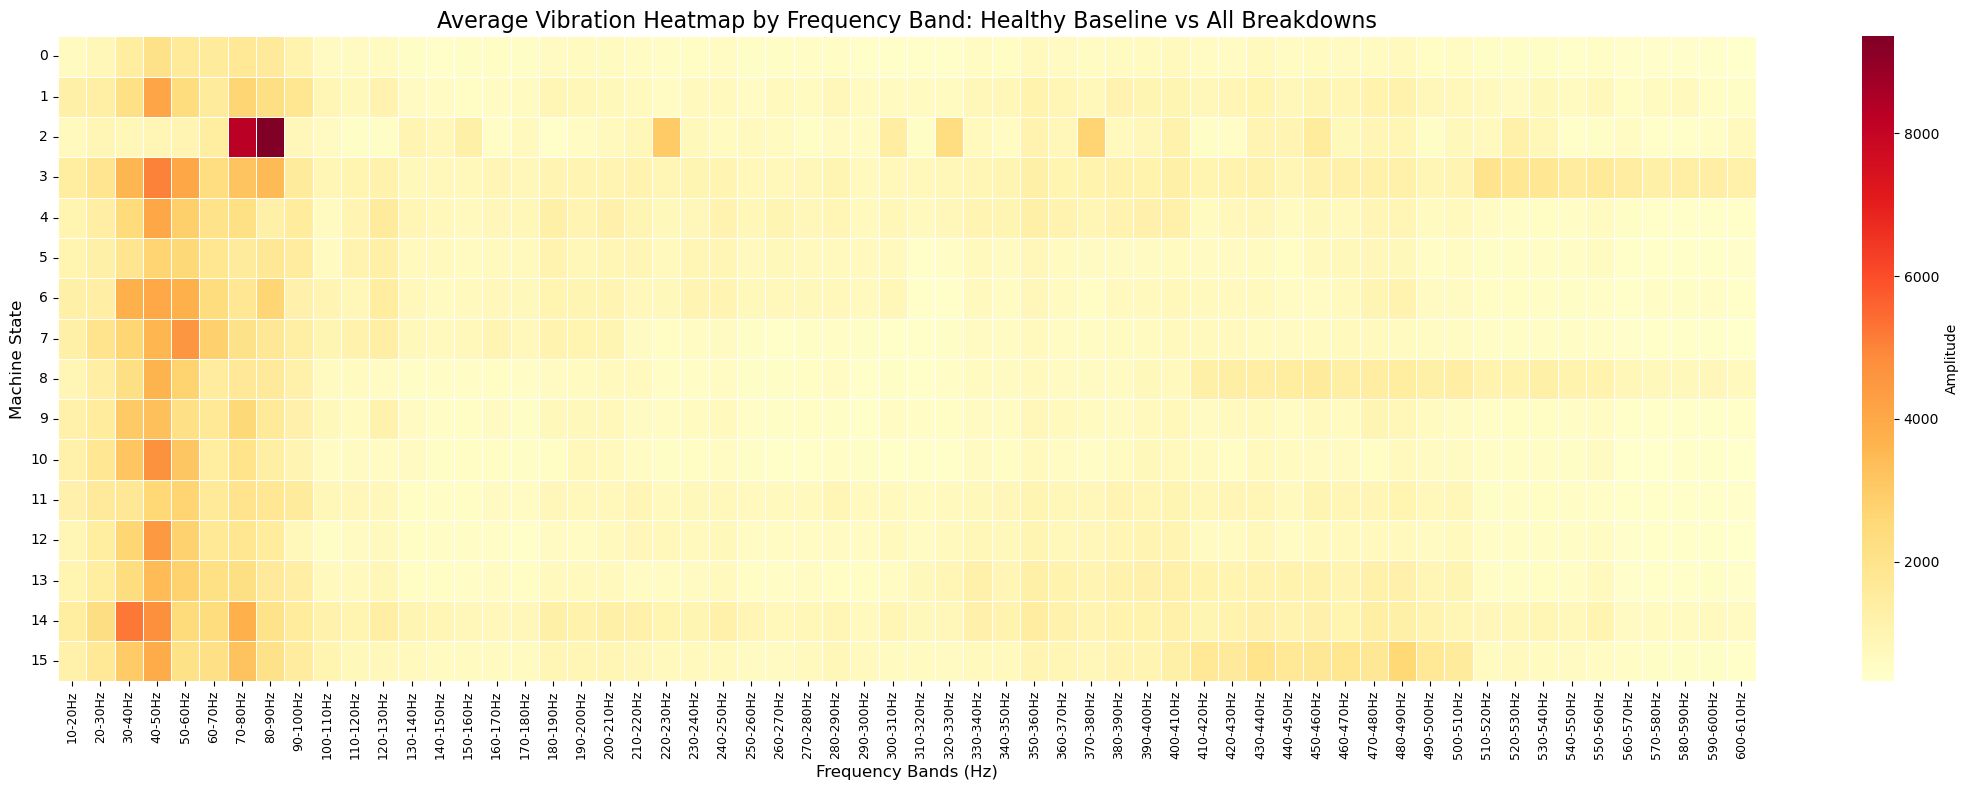

In [57]:
print("Generating Heatmap...")
plt.figure(figsize=(22, 8))

# Using a Yellow-Orange-Red color map (dark red = massive vibration)
sns.heatmap(df_heatmap, cmap="YlOrRd", annot=False, linewidths=.5, cbar_kws={'label': 'Amplitude'})

plt.title("Average Vibration Heatmap by Frequency Band: Healthy Baseline vs All Breakdowns", fontsize=16)
plt.xlabel("Frequency Bands (Hz)", fontsize=12)
plt.ylabel("Machine State", fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

#### The Bar Chart Comparison

Generating Bar Chart Comparisons for All Breakdowns...



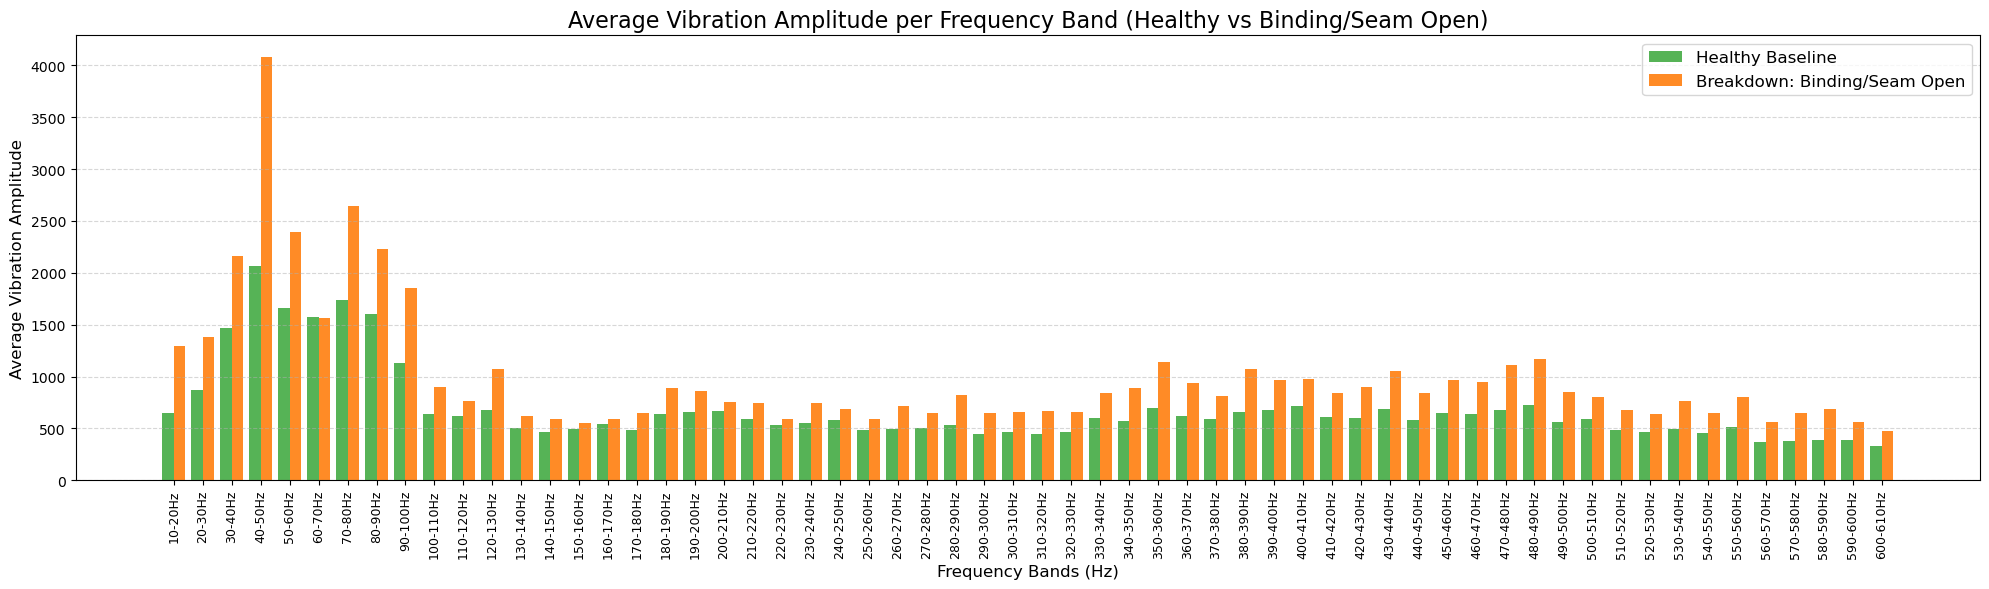

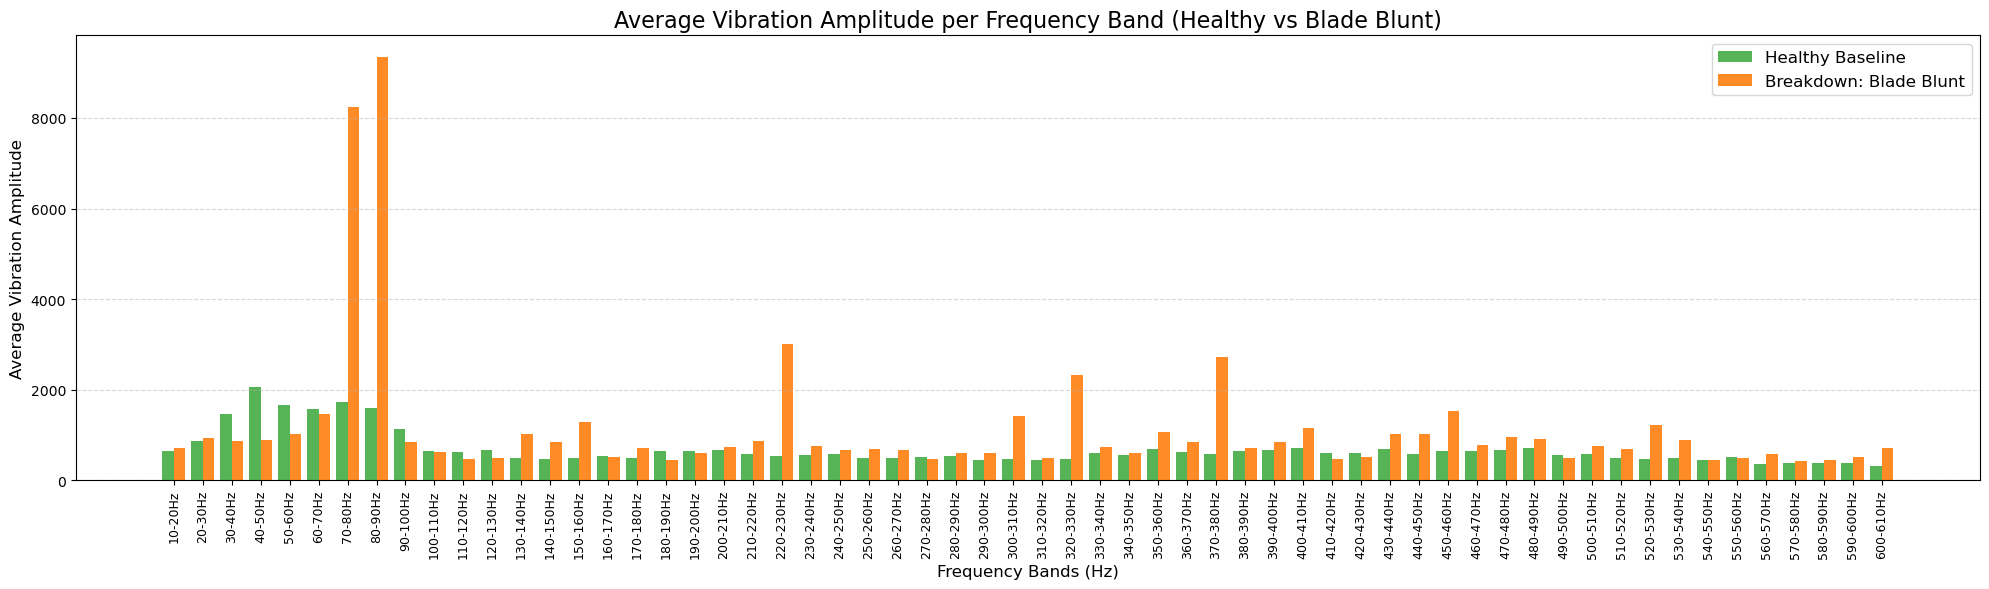

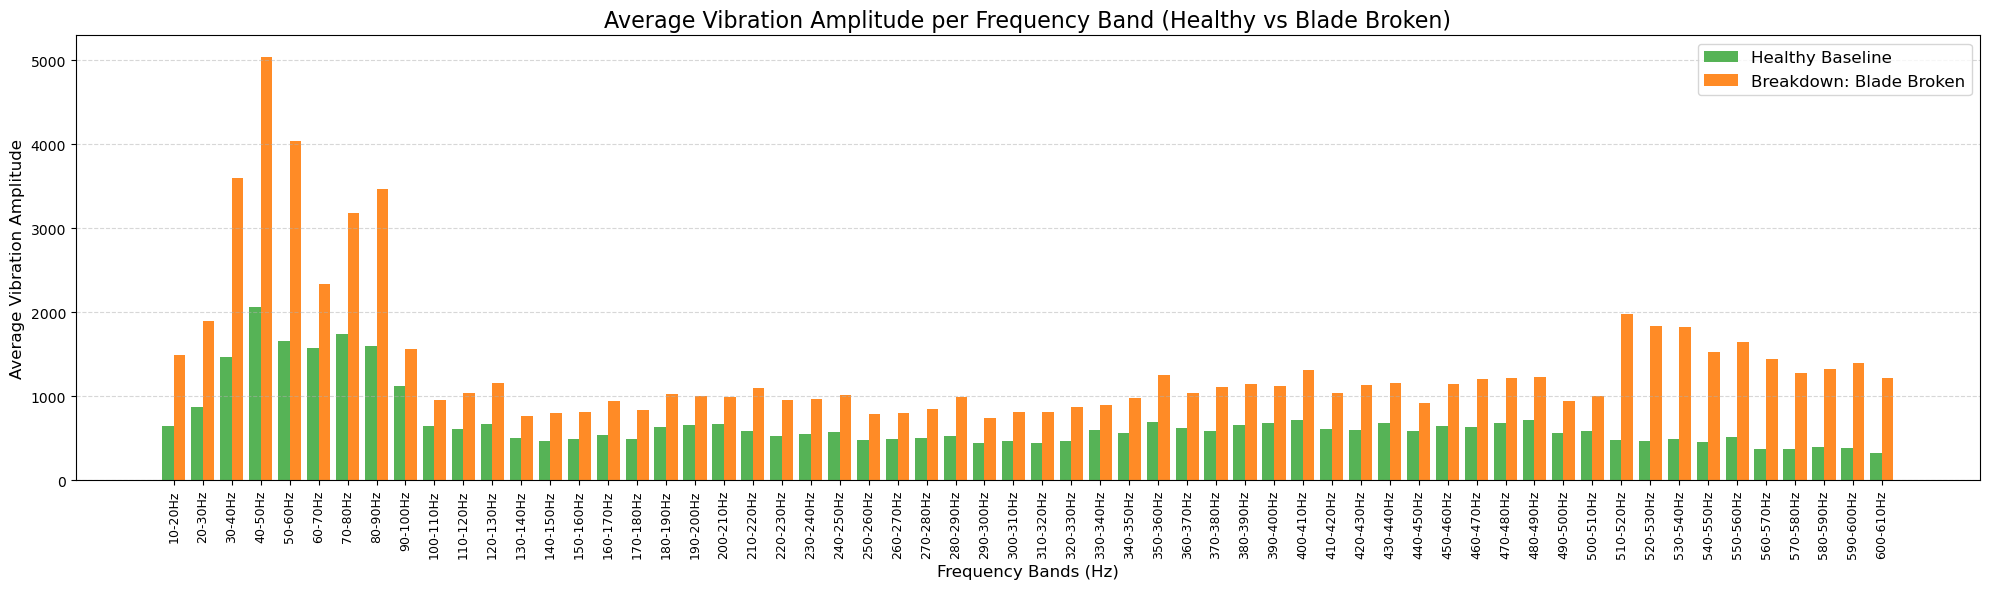

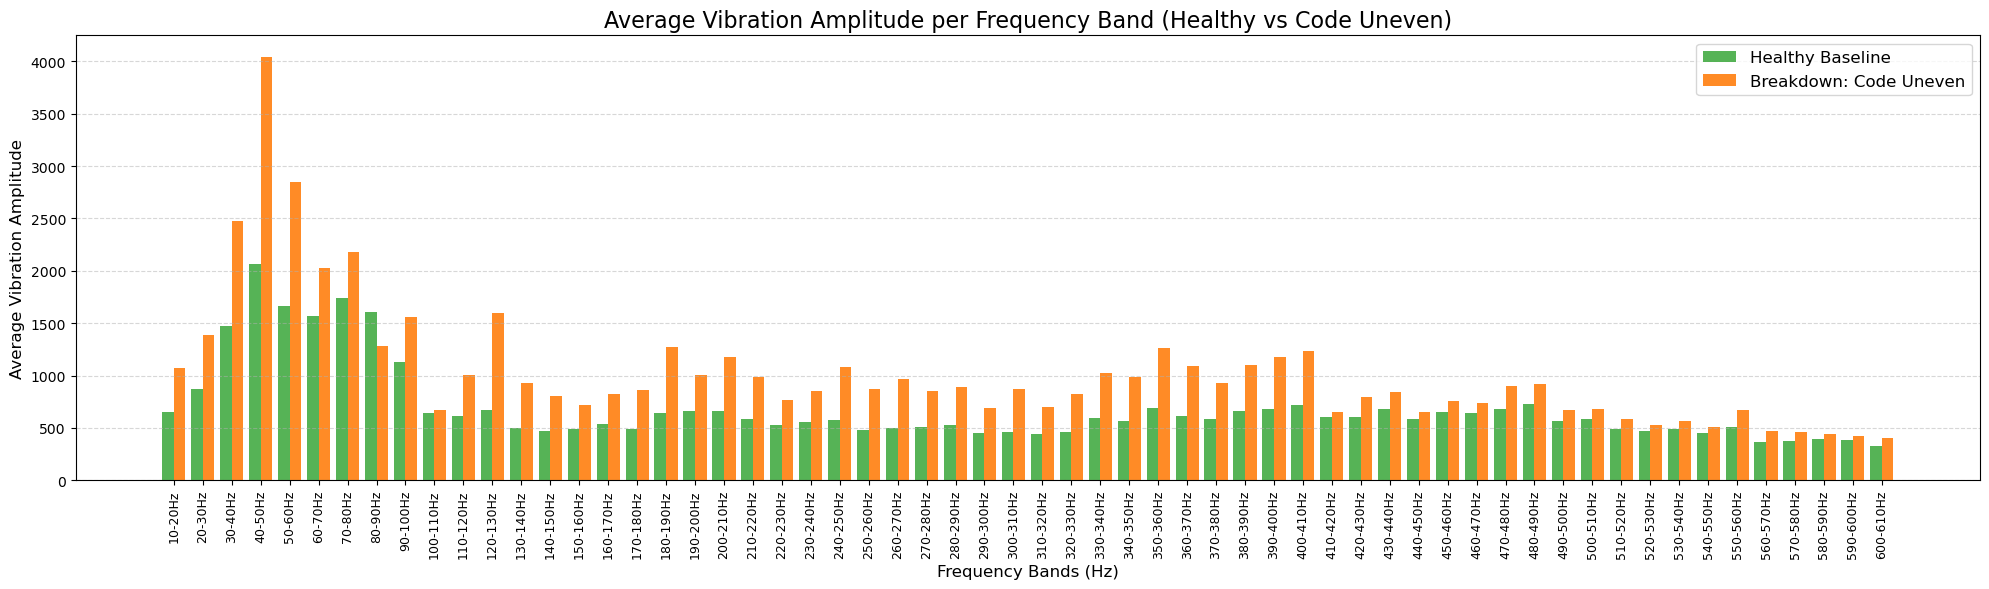

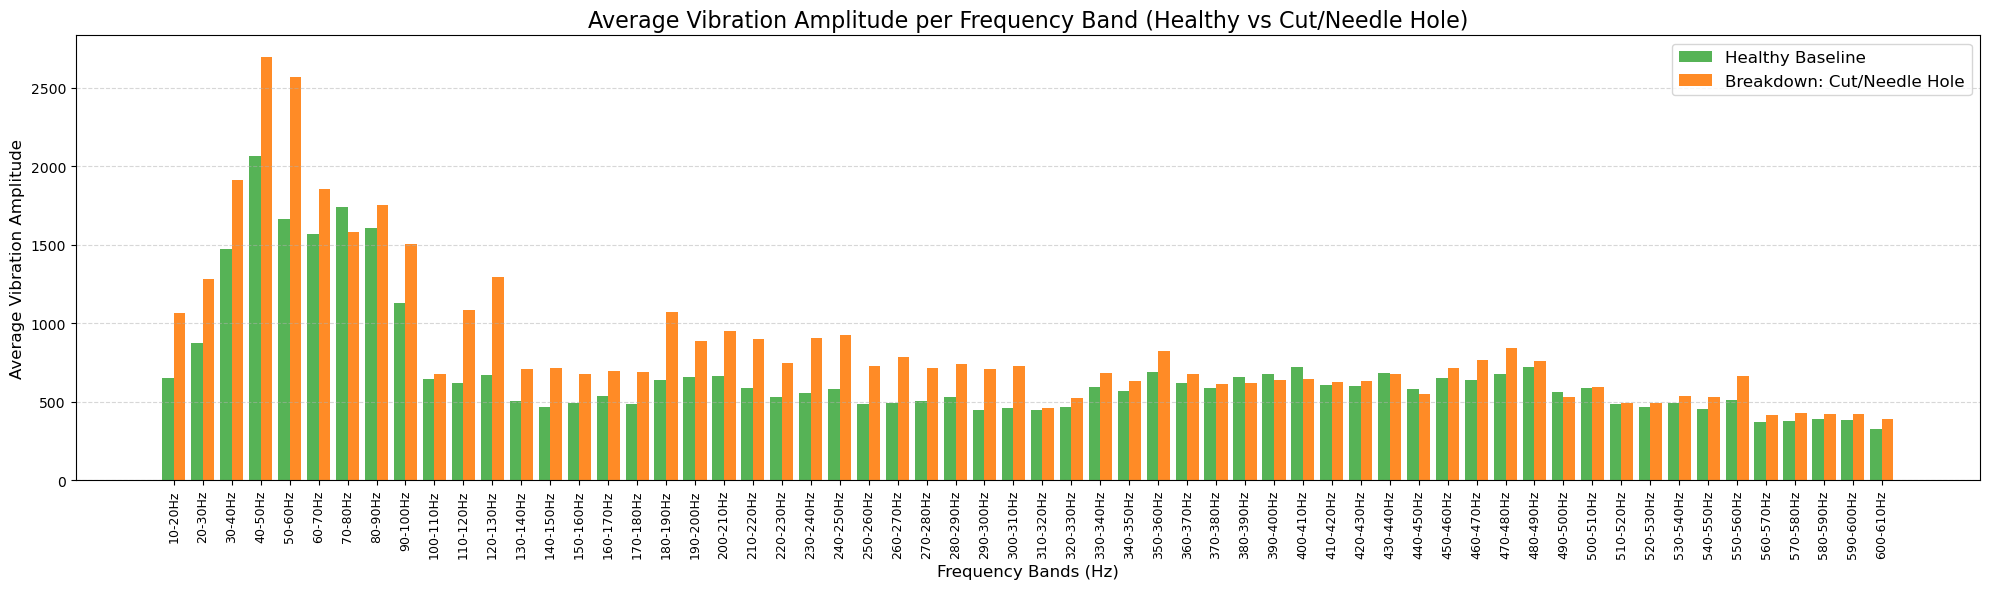

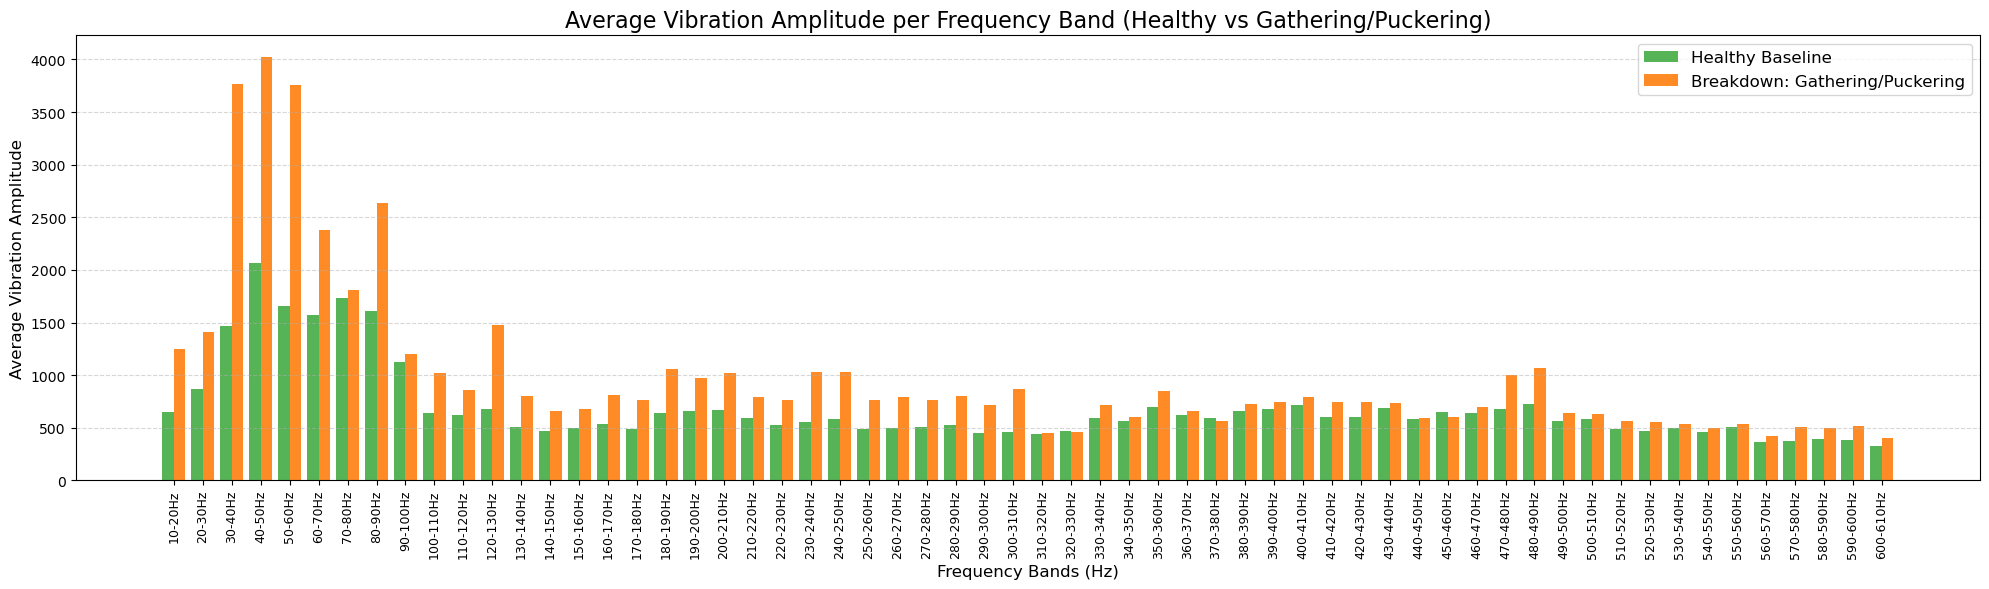

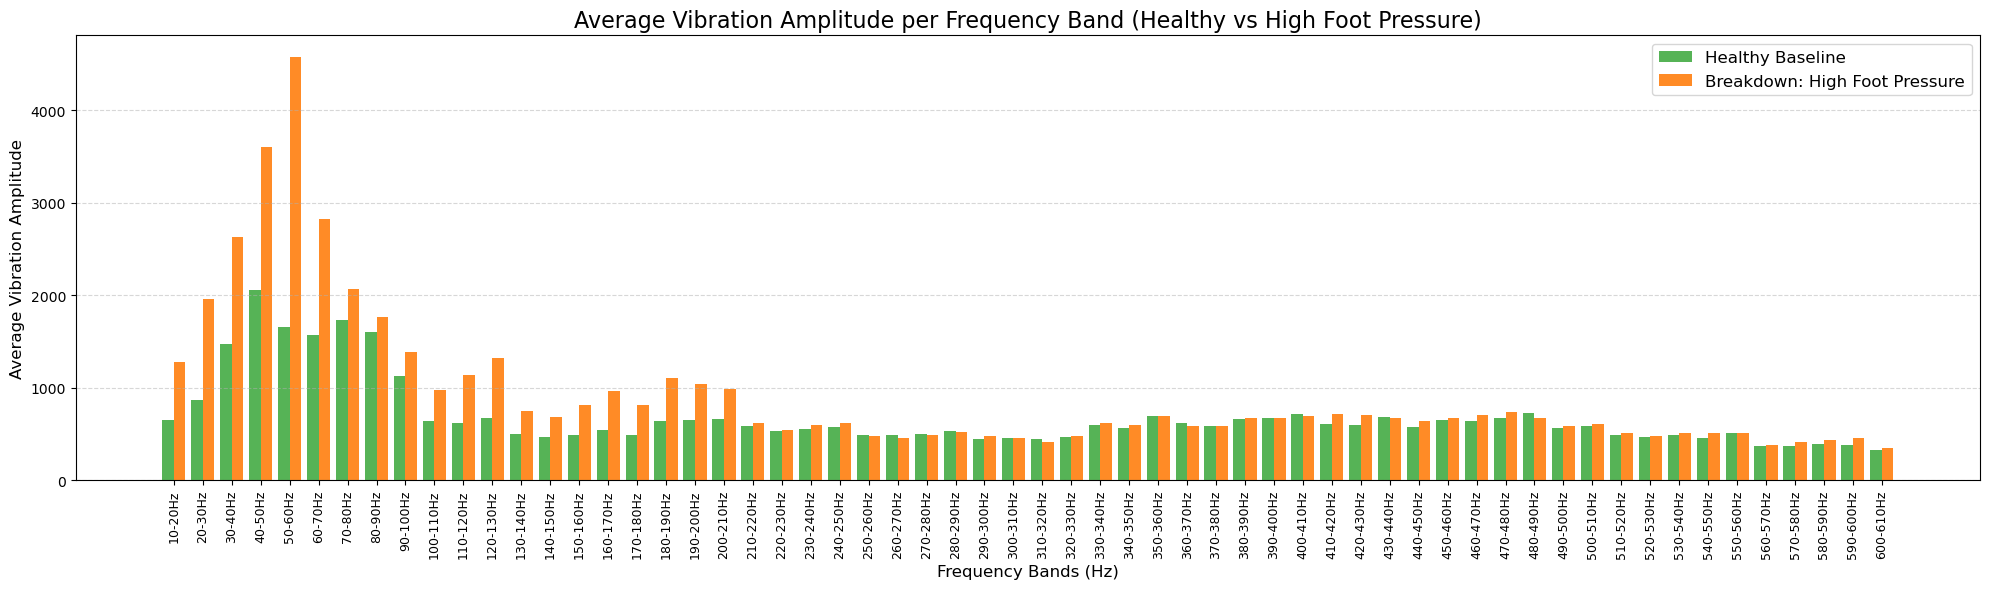

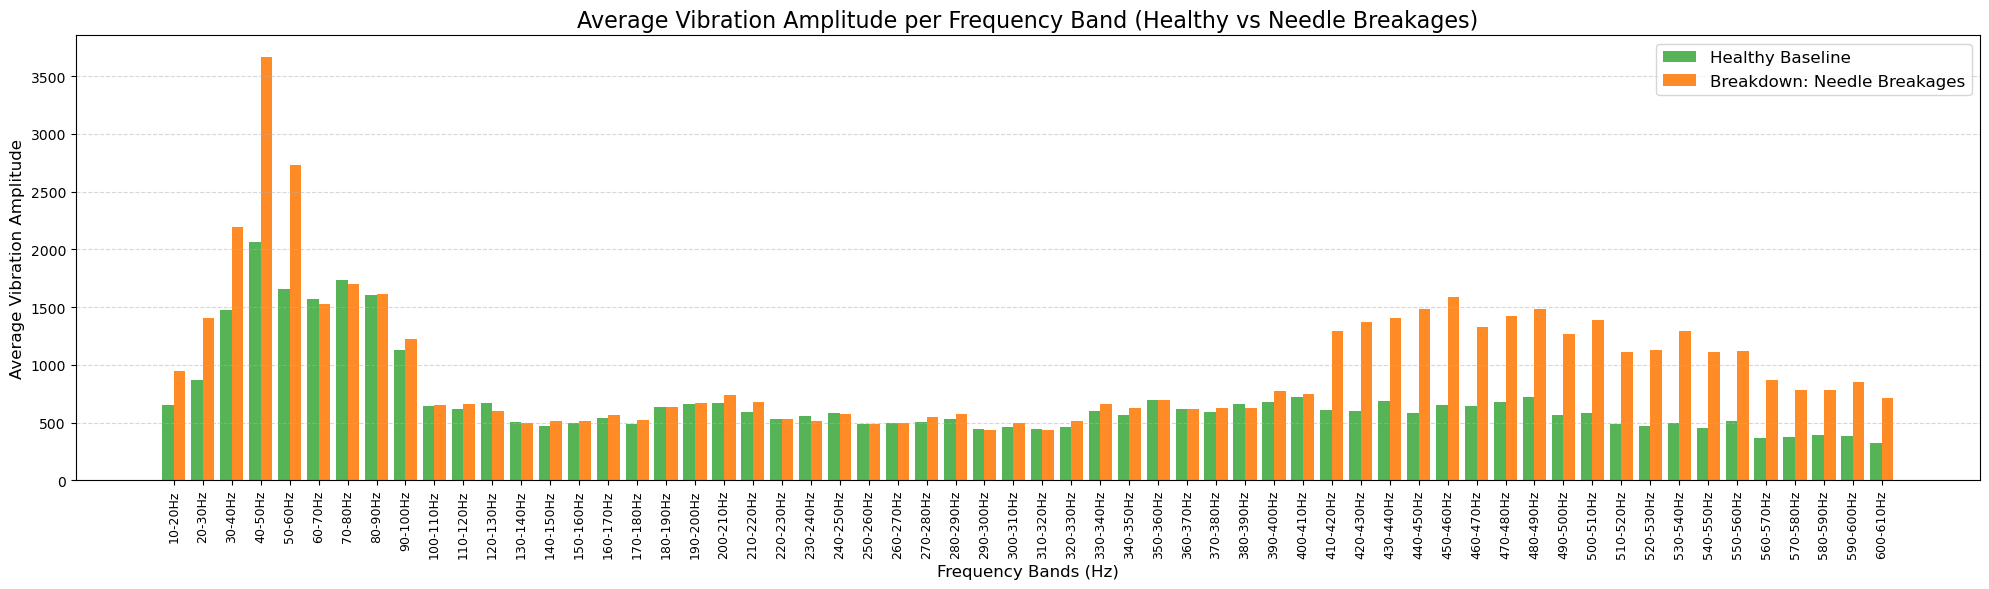

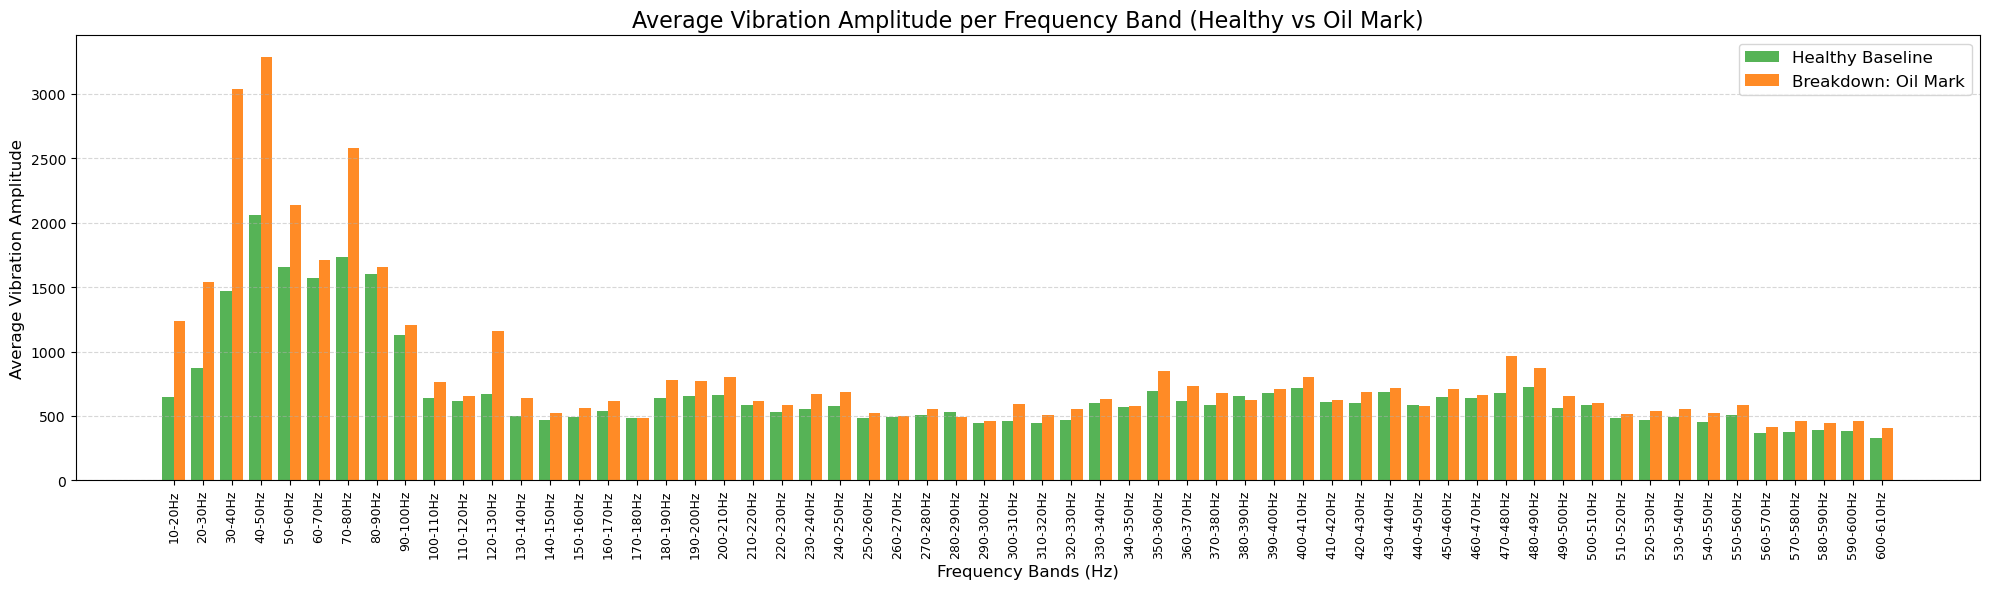

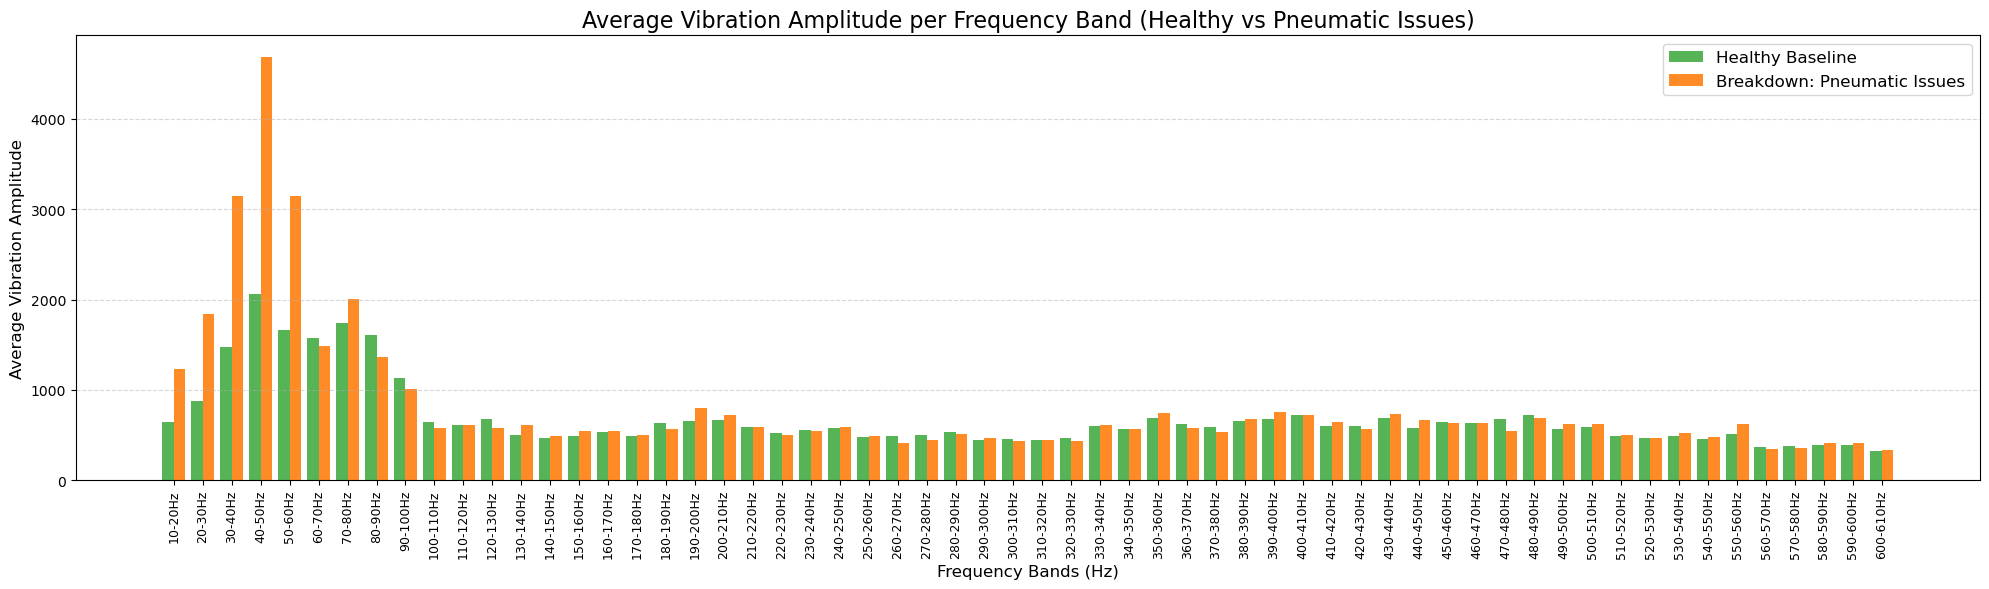

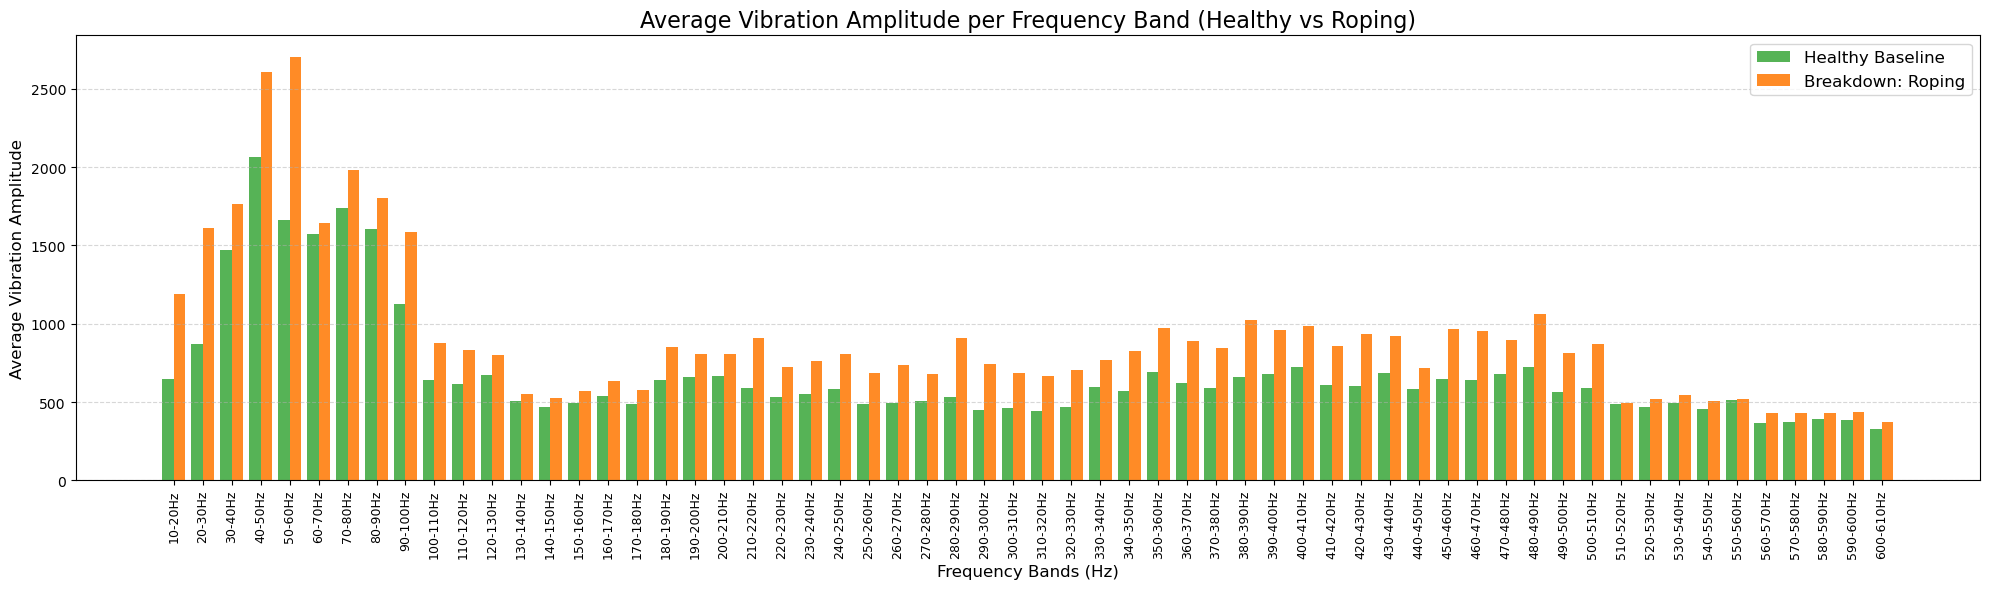

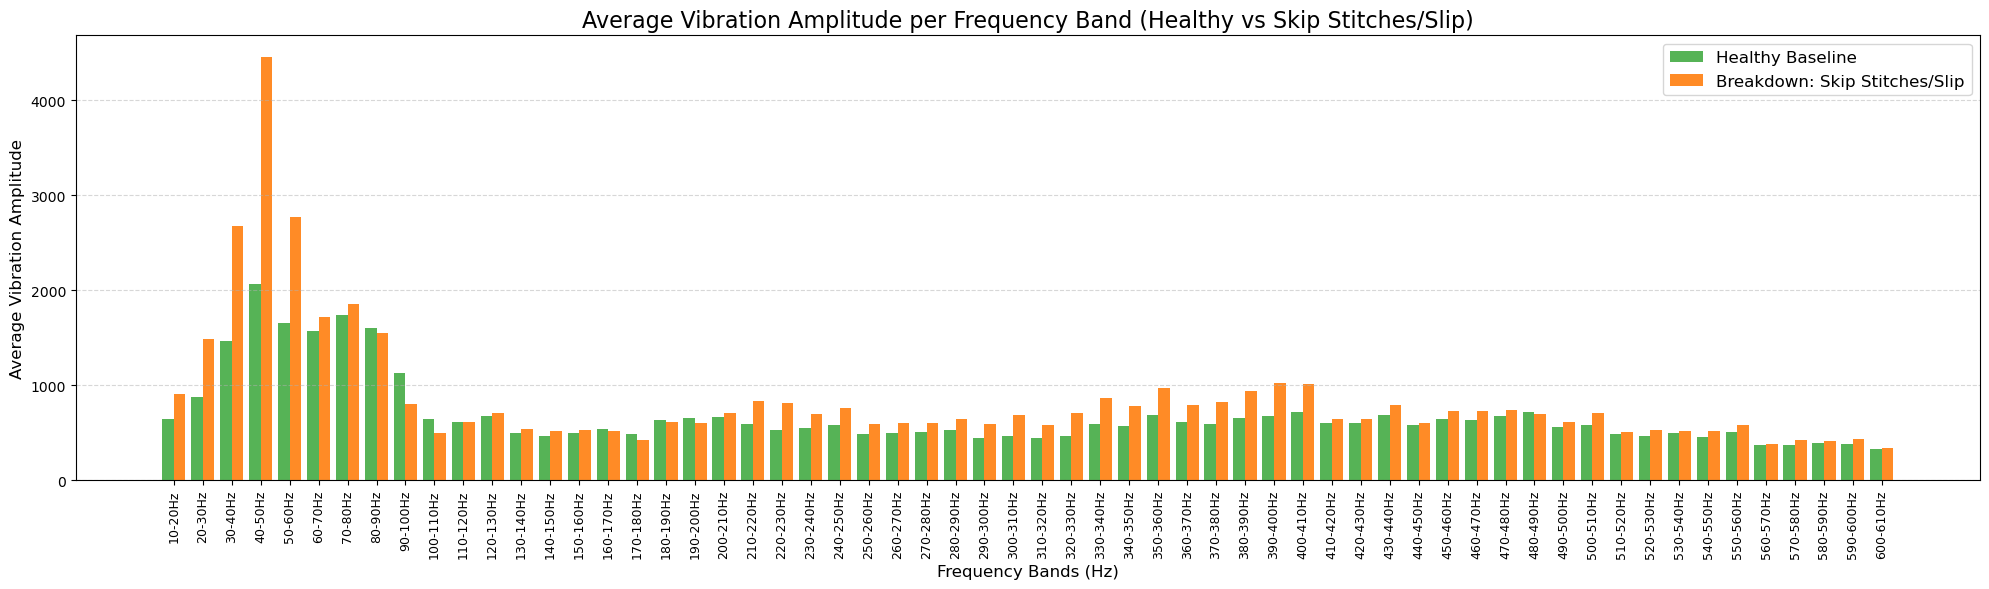

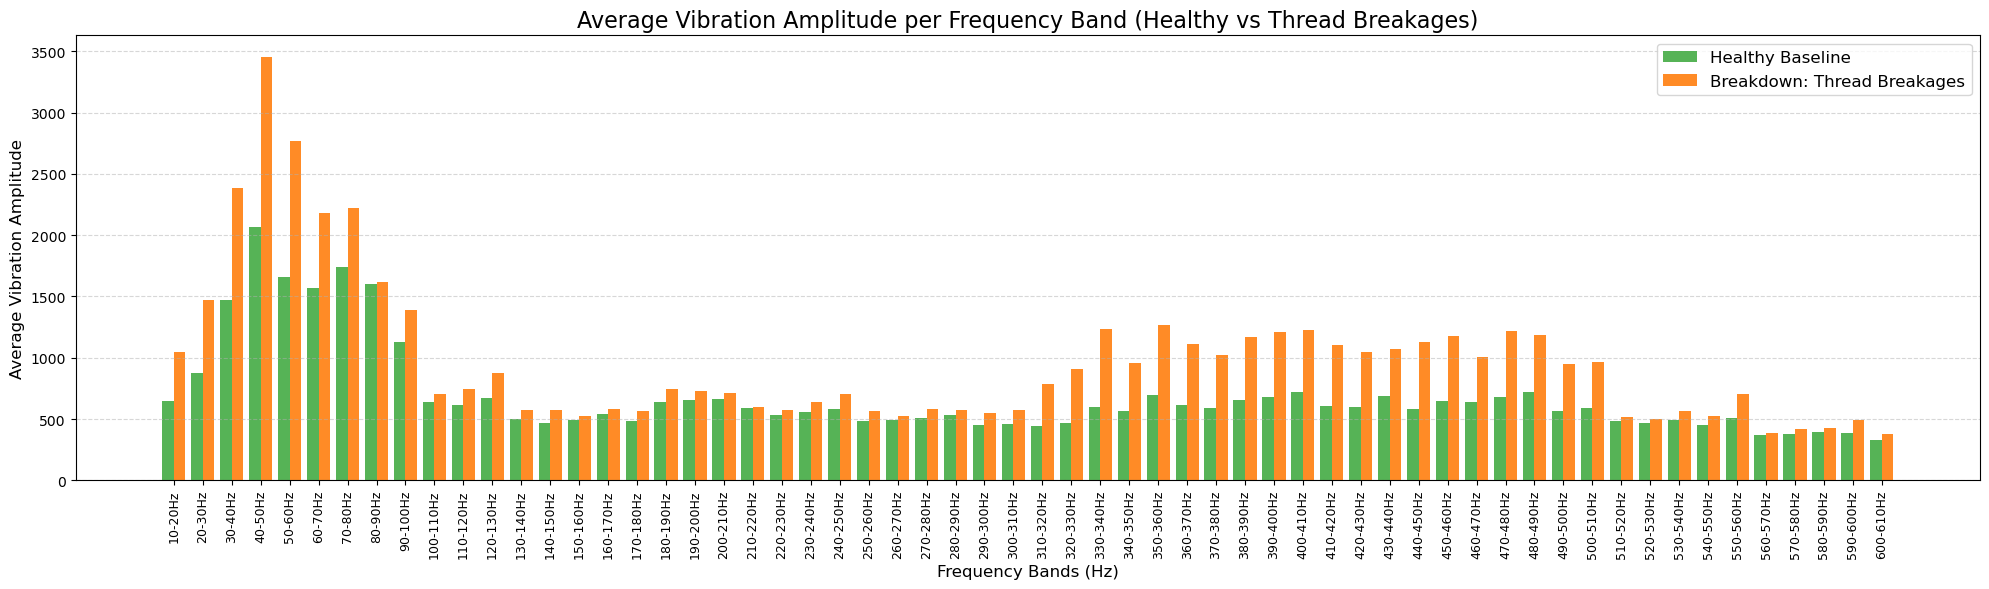

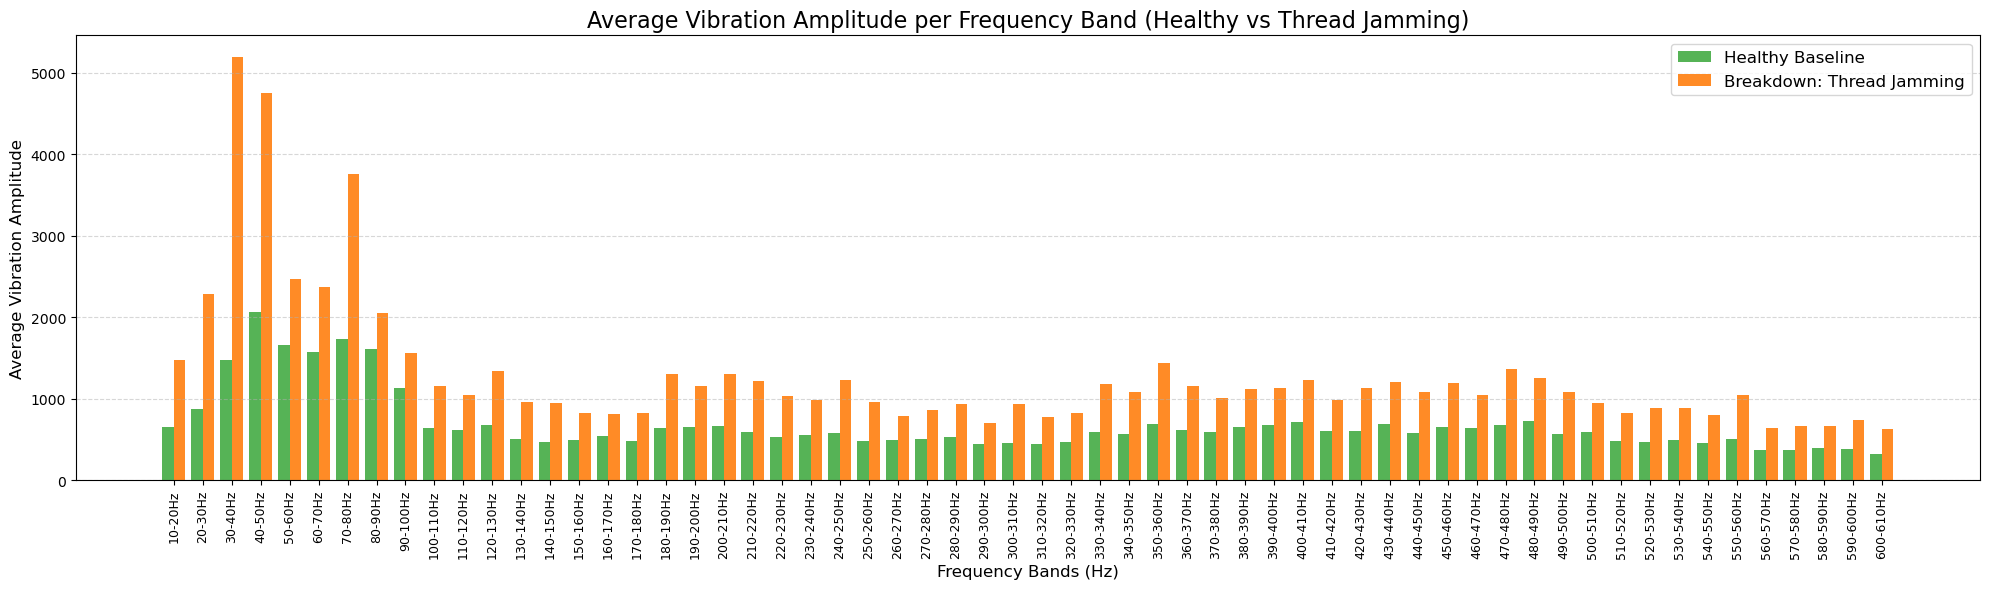

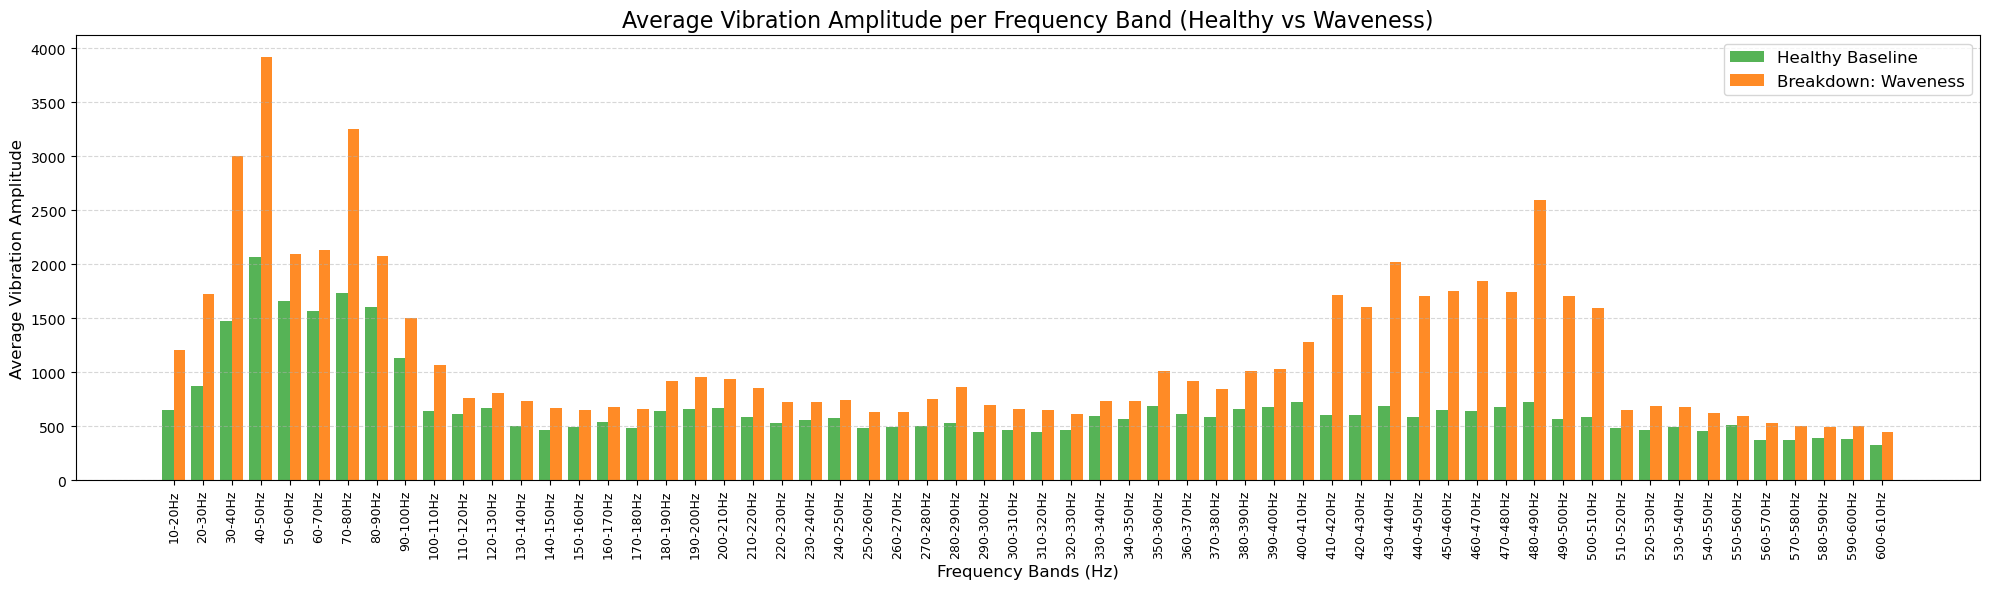


Generated 15 bar charts - one for each breakdown type!


In [ ]:
print("Generating Bar Chart Comparisons for All Breakdowns...\n")

# Get all breakdown types (exclude 'Healthy Baseline')
breakdowns = [idx for idx in df_heatmap.index if idx != 'Healthy Baseline']

# Loop through each breakdown and create a comparison chart
for fault_to_compare in breakdowns:
    plt.figure(figsize=(20, 6))
    
    # Set up the X-axis for frequency bands
    x = np.arange(len(df_heatmap.columns))
    width = 0.4  # Width of the bars
    
    # Plot Healthy Bars (Green)
    plt.bar(x - width/2, df_heatmap.loc['Healthy Baseline'], width, 
            label='Healthy Baseline', color='#2ca02c', alpha=0.8)
    
    # Plot Breakdown Bars (Orange)
    plt.bar(x + width/2, df_heatmap.loc[fault_to_compare], width, 
            label=f'Breakdown: {fault_to_compare}', color='#ff7f0e', alpha=0.9)
    
    plt.title(f'Average Vibration Amplitude per Frequency Band (Healthy vs {fault_to_compare})', fontsize=16)
    plt.xlabel('Frequency Bands (Hz)', fontsize=12)
    plt.ylabel('Average Vibration Amplitude', fontsize=12)
    
    # Apply the band labels (10-20Hz, 20-30Hz...) to the X-axis
    plt.xticks(x, df_heatmap.columns, rotation=90, fontsize=9)
    
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

print(f"\nGenerated {len(breakdowns)} bar charts - one for each breakdown type!")

#### The Spectrum Line Graph

In [ ]:
# ==========================================
# PLOT 3: Spectrum Line Graph
# ==========================================
print("Generating Spectrum Line Graph...")
plt.figure(figsize=(20, 6))

# You can change 'Waveness' to any of the 14 breakdowns
fault_to_plot = 'Waveness' 

# 1. Draw the Healthy Line (Green)
plt.plot(df_heatmap.columns, df_heatmap.loc['Healthy Baseline'], 
         label='Healthy Baseline', color='green', linewidth=2, marker='o', markersize=4)

# 2. Draw the Breakdown Line (Red)
if fault_to_plot in df_heatmap.index:
    plt.plot(df_heatmap.columns, df_heatmap.loc[fault_to_plot], 
             label=f'Breakdown: {fault_to_plot}', color='red', linewidth=2, marker='o', markersize=4)

plt.title(f'Continuous Vibration Spectrum: Healthy vs {fault_to_plot}', fontsize=16)
plt.xlabel('Frequency Bands (Hz)', fontsize=12)
plt.ylabel('Average Vibration Amplitude', fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.legend(fontsize=12)

# Add a grid to make it look like an engineering chart
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### The Box Plot for a Critical Frequency Band

In [ ]:
# ==========================================
# PLOT 4: Box Plot for Variance
# ==========================================
print("Generating Box Plot...")

# Change this to whichever frequency band you want to investigate!
target_band = '40-50Hz' 

if target_band in df_healthy_vib.columns and target_band in df_b_all.columns:
    # Gather all the raw healthy data for this specific frequency band
    healthy_box_data = pd.DataFrame({
        'Amplitude': df_healthy_vib[target_band],
        'State': 'Healthy Baseline'
    })
    
    # Gather all the raw breakdown data for this specific frequency band
    broken_box_data = pd.DataFrame({
        'Amplitude': df_b_all[target_band],
        'State': df_b_all['Fault_Type']
    })
    
    # Glue them together for plotting
    df_box = pd.concat([healthy_box_data, broken_box_data])
    
    plt.figure(figsize=(16, 8))
    sns.boxplot(x='State', y='Amplitude', data=df_box, palette='Set3')
    
    plt.title(f'Vibration Variance at the {target_band} Band (All 700+ Records)', fontsize=16)
    plt.xlabel('Machine State (Healthy vs Breakdowns)', fontsize=12)
    plt.ylabel(f'Amplitude at {target_band}', fontsize=12)
    
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print(f"Band {target_band} not found. Make sure you included the 'Hz' at the end!")

#### The PCA Scatter Plot (The AI Predictability Test)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ==========================================
# PLOT 5: PCA Scatter Plot (AI Predictability)
# ==========================================
print("Generating PCA Scatter Plot (This may take a second)...")

# 1. Prepare the raw healthy data
df_h_pca = df_healthy_vib.copy()
df_h_pca['Label'] = 'Healthy Baseline'

# 2. Prepare the raw breakdown data
df_b_pca = df_b_all.copy()
df_b_pca['Label'] = df_b_all['Fault_Type']
df_b_pca = df_b_pca.drop(columns=['Fault_Type'], errors='ignore')

# 3. Combine them into one massive table
df_pca_full = pd.concat([df_h_pca, df_b_pca]).fillna(0)

# Separate the numbers (X) from the text labels (y)
X = df_pca_full.drop(columns=['Label'])
y = df_pca_full['Label']

# 4. Standardize the data (AI models need the data scaled properly)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Apply PCA math to crush 60 dimensions down to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a clean table for the Scatter Plot
df_plot_pca = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'Machine State': y
})

# 6. Draw the Scatter Plot
plt.figure(figsize=(16, 10))
sns.scatterplot(x='PCA1', y='PCA2', hue='Machine State', data=df_plot_pca, 
                palette='tab20', s=70, alpha=0.8, edgecolor='black')

plt.title('PCA Scatter Plot: Can the AI Tell the Difference Between Faults?', fontsize=18)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% of data)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% of data)', fontsize=12)

# Move the legend outside the chart so it doesn't cover the dots
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()